# Latent Communication Between Language Models

This notebook contains experiments on transferring information between language models through hidden representations instead of text.

The main goal is to study how the choice of token position and transformer layer affects the quality of latent information transfer.

Models used:
- DistilGPT-2
- GPT-2

In [ ]:
!pip install transformers torch accelerate

In [ ]:
import torch
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

print("Imports loaded")

Imports loaded


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

model = AutoModelForCausalLM.from_pretrained("distilgpt2")
model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

model_b = AutoModelForCausalLM.from_pretrained("gpt2")
model_b.eval()

for parameter in model_b.parameters():
    parameter.requires_grad = False

print("Models loaded")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Models loaded


In [ ]:
objects = [
    "key", "ball", "book", "coin", "pen",
    "phone", "cup", "toy", "card", "bottle"
]

colors = [
    "red", "blue", "green",
    "yellow", "black", "white"
]

all_data = []

for obj in objects:
    for color in colors:
        text = f"The {obj} is in the {color} box."
        answer = f" {color}"
        all_data.append((text, answer))

random.seed(42)
random.shuffle(all_data)

split_index = int(len(all_data) * 0.7)

train_data = all_data[:split_index]
test_data = all_data[split_index:]

print("Train:", len(train_data))
print("Test:", len(test_data))

Train: 42
Test: 18


In [ ]:
def train_adapter(layer, position, seed=42):
    torch.manual_seed(seed)

    adapter = torch.nn.Linear(768, 768)

    optimizer = torch.optim.Adam(
        adapter.parameters(),
        lr=0.0001
    )

    best_loss = float("inf")
    best_adapter_state = None

    for epoch in range(20):
        total_loss = 0

        for text, answer in train_data:
            inputs_a = tokenizer(
                text,
                return_tensors="pt"
            )

            outputs_a = model(
                **inputs_a,
                output_hidden_states=True
            )

            message = outputs_a.hidden_states[layer][0, position]

            adapted = adapter(message)
            input_b = adapted.unsqueeze(0).unsqueeze(0)

            output_b = model(
                inputs_embeds=input_b
            )

            answer_id = tokenizer(answer)["input_ids"][0]

            loss = torch.nn.functional.cross_entropy(
                output_b.logits[0, -1].unsqueeze(0),
                torch.tensor([answer_id])
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_data)

        if average_loss < best_loss:
            best_loss = average_loss
            best_adapter_state = copy.deepcopy(adapter.state_dict())

    adapter.load_state_dict(best_adapter_state)

    return adapter

In [ ]:
def test_adapter(adapter, layer, position):
    correct = 0

    for text, answer in test_data:
        inputs_a = tokenizer(
            text,
            return_tensors="pt"
        )

        outputs_a = model(
            **inputs_a,
            output_hidden_states=True
        )

        message = outputs_a.hidden_states[layer][0, position]

        adapted = adapter(message)
        input_b = adapted.unsqueeze(0).unsqueeze(0)

        output_b = model(
            inputs_embeds=input_b
        )

        predicted_id = torch.argmax(
            output_b.logits[0, -1]
        ).item()

        predicted_token = tokenizer.decode([predicted_id])

        if predicted_token == answer:
            correct += 1

    return correct / len(test_data)

In [ ]:
def test_without_adapter(layer, position):
    correct = 0

    for text, answer in test_data:
        inputs_a = tokenizer(
            text,
            return_tensors="pt"
        )

        outputs_a = model(
            **inputs_a,
            output_hidden_states=True
        )

        message = outputs_a.hidden_states[layer][0, position]

        input_b = message.unsqueeze(0).unsqueeze(0)

        output_b = model(
            inputs_embeds=input_b
        )

        predicted_id = torch.argmax(
            output_b.logits[0, -1]
        ).item()

        predicted_token = tokenizer.decode([predicted_id])

        if predicted_token == answer:
            correct += 1

    return correct / len(test_data)

In [ ]:
def train_cross_model_adapter(layer, position, seed=42):
    torch.manual_seed(seed)

    adapter = torch.nn.Linear(768, 768)

    optimizer = torch.optim.Adam(
        adapter.parameters(),
        lr=0.0001
    )

    best_loss = float("inf")
    best_adapter_state = None

    for epoch in range(20):
        total_loss = 0

        for text, answer in train_data:
            inputs_a = tokenizer(
                text,
                return_tensors="pt"
            )

            outputs_a = model(
                **inputs_a,
                output_hidden_states=True
            )

            message = outputs_a.hidden_states[layer][0, position]

            adapted = adapter(message)
            input_b = adapted.unsqueeze(0).unsqueeze(0)

            output_b = model_b(
                inputs_embeds=input_b
            )

            answer_id = tokenizer(answer)["input_ids"][0]

            loss = torch.nn.functional.cross_entropy(
                output_b.logits[0, -1].unsqueeze(0),
                torch.tensor([answer_id])
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_data)

        if average_loss < best_loss:
            best_loss = average_loss
            best_adapter_state = copy.deepcopy(adapter.state_dict())

    adapter.load_state_dict(best_adapter_state)

    return adapter

In [ ]:
def test_cross_model_adapter(adapter, layer, position):
    correct = 0

    for text, answer in test_data:
        inputs_a = tokenizer(
            text,
            return_tensors="pt"
        )

        outputs_a = model(
            **inputs_a,
            output_hidden_states=True
        )

        message = outputs_a.hidden_states[layer][0, position]

        adapted = adapter(message)
        input_b = adapted.unsqueeze(0).unsqueeze(0)

        output_b = model_b(
            inputs_embeds=input_b
        )

        predicted_id = torch.argmax(
            output_b.logits[0, -1]
        ).item()

        predicted_token = tokenizer.decode([predicted_id])

        if predicted_token == answer:
            correct += 1

    return correct / len(test_data)

In [ ]:
matrix_results = {
    0: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0},
    1: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0},
    2: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0},
    3: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0},
    4: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0},

    5: {
        0: 1.0,
        1: 1.0,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 1.0,
        6: 1.0
    },

    6: {
        0: 0.0,
        1: 0.9444444444444444,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 0.9444444444444444,
        6: 0.2222222222222222
    },

    7: {
        0: 0.0,
        1: 0.7777777777777778,
        2: 0.8333333333333334,
        3: 0.8333333333333334,
        4: 0.7777777777777778,
        5: 0.4444444444444444,
        6: 0.0
    }
}

print("Main results loaded")

Main results loaded


## Token position and layer analysis

For each token position and transformer layer, a separate linear adapter was trained to transfer the hidden representation into the receiving model.

The target was to recover the color mentioned in the sentence.

The heatmap below shows test accuracy for each combination of token position and layer.

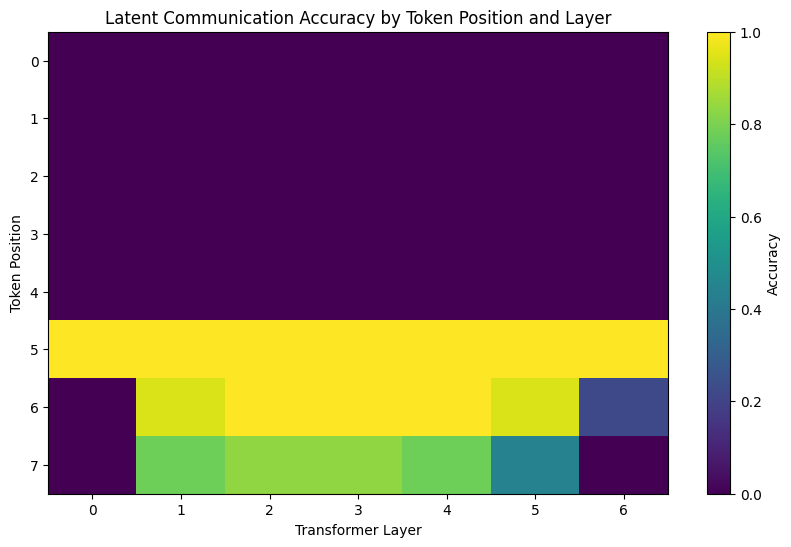

In [ ]:
heatmap_data = np.zeros((8, 7))

for position in range(8):
    for layer in range(7):
        heatmap_data[position, layer] = matrix_results[position][layer]

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_data,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Accuracy")
plt.xlabel("Transformer Layer")
plt.ylabel("Token Position")

plt.xticks(range(7))
plt.yticks(range(8))

plt.title("Latent Communication Accuracy by Token Position and Layer")

plt.show()

In [ ]:
all_data_template2 = []

for obj in objects:
    for color in colors:
        text = f"The {color} box contains the {obj}."
        answer = f" {color}"

        all_data_template2.append((text, answer))

random.seed(42)

all_data_template2_shuffled = all_data_template2.copy()
random.shuffle(all_data_template2_shuffled)

split_index = int(len(all_data_template2_shuffled) * 0.7)

train_data_template2 = all_data_template2_shuffled[:split_index]
test_data_template2 = all_data_template2_shuffled[split_index:]

print("Template 2")
print("Train:", len(train_data_template2))
print("Test:", len(test_data_template2))

Template 2
Train: 42
Test: 18


In [ ]:
matrix_results_template2 = {
    0: {
        0: 0.05555555555555555,
        1: 0.05555555555555555,
        2: 0.05555555555555555,
        3: 0.05555555555555555,
        4: 0.05555555555555555,
        5: 0.05555555555555555,
        6: 0.05555555555555555
    },

    1: {
        0: 1.0,
        1: 1.0,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 1.0,
        6: 1.0
    },

    2: {
        0: 0.05555555555555555,
        1: 1.0,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 1.0,
        6: 1.0
    },

    3: {
        0: 0.05555555555555555,
        1: 1.0,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 1.0,
        6: 1.0
    },

    4: {
        0: 0.05555555555555555,
        1: 1.0,
        2: 1.0,
        3: 1.0,
        4: 1.0,
        5: 1.0,
        6: 1.0
    },

    5: {
        0: 0.0,
        1: 0.0,
        2: 0.0,
        3: 0.0,
        4: 0.0,
        5: 0.0,
        6: 0.0
    },

    6: {
        0: 0.05555555555555555,
        1: 0.3888888888888889,
        2: 0.3888888888888889,
        3: 0.2777777777777778,
        4: 0.5,
        5: 0.6111111111111112,
        6: 0.4444444444444444
    }
}

print("Template 2 results loaded")

Template 2 results loaded


## Alternative sentence template

To check whether the observed pattern depends on a single sentence structure, the same experiment was repeated with a different template:

`The red box contains the key.`

The target remained the color. The heatmap below shows how the result changes when the position of the relevant information in the sentence is different.

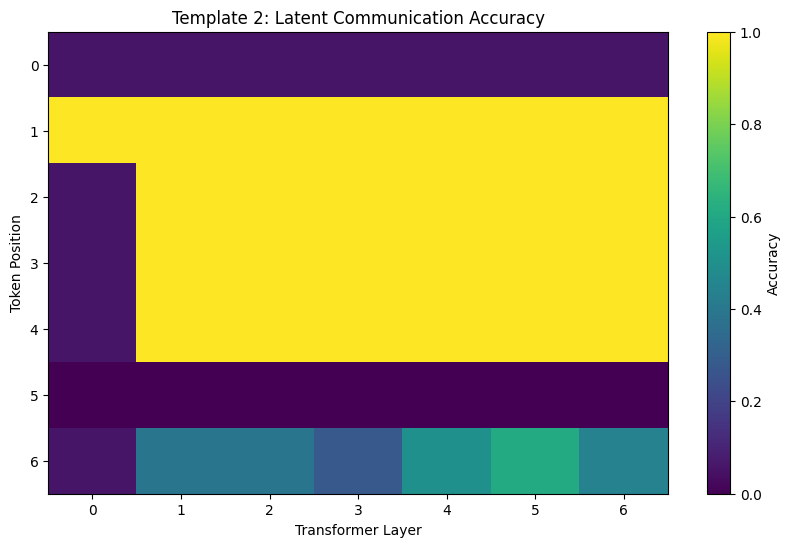

In [ ]:
heatmap_data_template2 = np.zeros((7, 7))

for position in range(7):
    for layer in range(7):
        heatmap_data_template2[position, layer] = matrix_results_template2[position][layer]

plt.figure(figsize=(10, 6))

plt.imshow(
    heatmap_data_template2,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Accuracy")
plt.xlabel("Transformer Layer")
plt.ylabel("Token Position")

plt.xticks(range(7))
plt.yticks(range(7))

plt.title("Template 2: Latent Communication Accuracy")

plt.show()

## Adapter baseline

To test whether the learned adapter is actually necessary, the same hidden states were also passed directly into the receiving model without any learned transformation.

The comparison below shows accuracy with and without the adapter for several representative hidden-state sources.

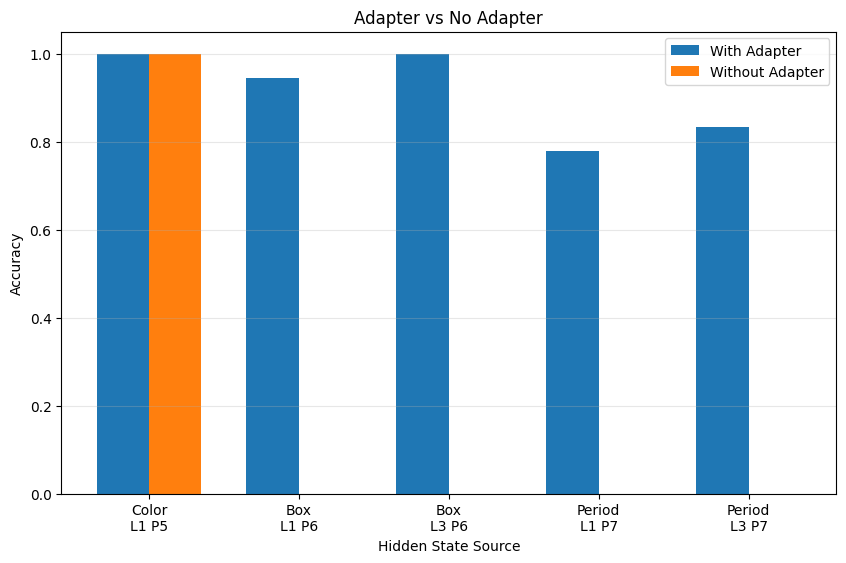

In [ ]:
labels = [
    "Color\nL1 P5",
    "Box\nL1 P6",
    "Box\nL3 P6",
    "Period\nL1 P7",
    "Period\nL3 P7"
]

with_adapter = [
    1.0,
    0.944,
    1.0,
    0.778,
    0.833
]

without_adapter = [
    1.0,
    0.0,
    0.0,
    0.0,
    0.0
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    with_adapter,
    width,
    label="With Adapter"
)

plt.bar(
    x + width / 2,
    without_adapter,
    width,
    label="Without Adapter"
)

plt.ylabel("Accuracy")
plt.xlabel("Hidden State Source")
plt.title("Adapter vs No Adapter")

plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## Cross-model latent communication

The previous experiments used DistilGPT-2 as both the source and receiving model.

To test whether latent transfer also works between different models, the receiving model was replaced with GPT-2 while DistilGPT-2 remained the source model.

A separate linear adapter was trained for each selected hidden-state source. The results below show mean test accuracy across five random seeds. Error bars represent standard deviation.

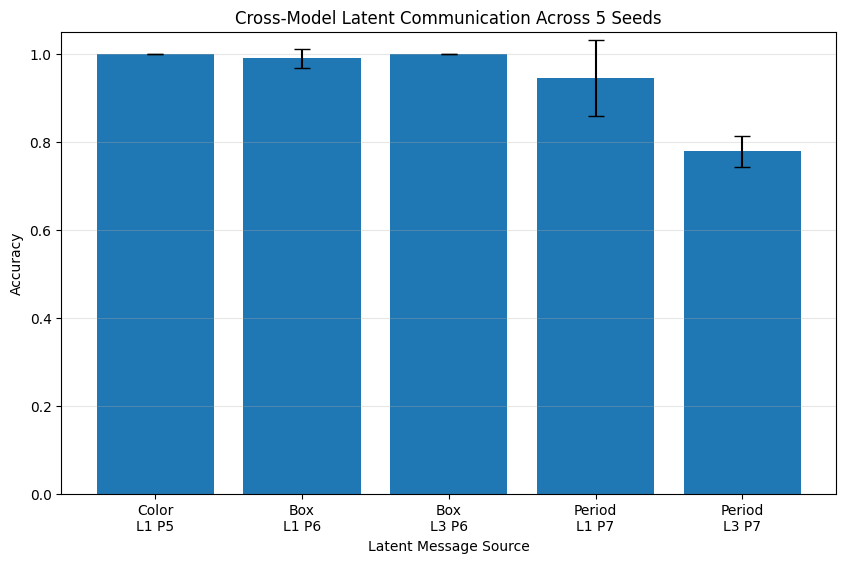

In [ ]:
cross_labels = [
    "Color\nL1 P5",
    "Box\nL1 P6",
    "Box\nL3 P6",
    "Period\nL1 P7",
    "Period\nL3 P7"
]

cross_means = [
    1.000,
    0.989,
    1.000,
    0.944,
    0.778
]

cross_stds = [
    0.000,
    0.022,
    0.000,
    0.086,
    0.035
]

x = np.arange(len(cross_labels))

plt.figure(figsize=(10, 6))

plt.bar(
    x,
    cross_means,
    yerr=cross_stds,
    capsize=6
)

plt.xticks(x, cross_labels)
plt.ylabel("Accuracy")
plt.xlabel("Latent Message Source")
plt.title("Cross-Model Latent Communication Across 5 Seeds")

plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

plt.show()

## Object information

To check whether the effect is specific to colors, an additional experiment was performed using the object as the target instead.

The plot below shows how well object information can be recovered from different token positions at transformer layer 1.

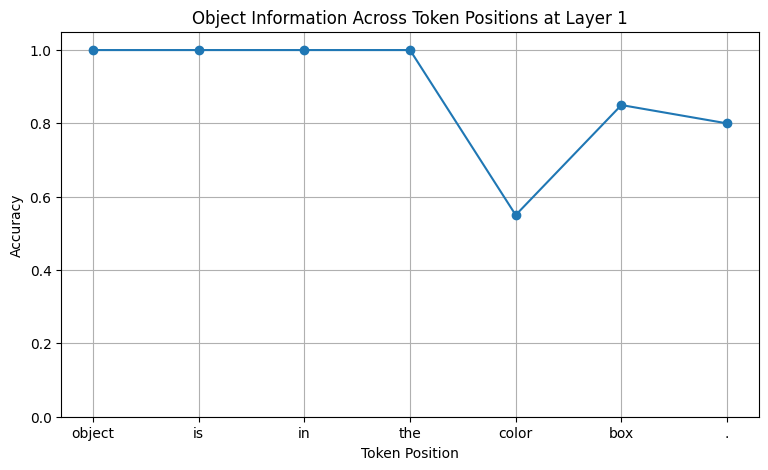

In [ ]:
positions = [1, 2, 3, 4, 5, 6, 7]

object_accuracies = [
    1.0,
    1.0,
    1.0,
    1.0,
    0.55,
    0.85,
    0.80
]

plt.figure(figsize=(9, 5))

plt.plot(
    positions,
    object_accuracies,
    marker="o"
)

plt.xlabel("Token Position")
plt.ylabel("Accuracy")
plt.title("Object Information Across Token Positions at Layer 1")

plt.xticks(
    positions,
    ["object", "is", "in", "the", "color", "box", "."]
)

plt.ylim(0, 1.05)
plt.grid(True)

plt.show()

## Main observations

The experiments suggest that latent information transfer depends strongly on both token position and transformer layer.

Hidden states taken directly from the target token are usually easy to decode, while information stored in later contextual tokens varies substantially across layers.

A learned linear adapter is especially important when the relevant information is encoded indirectly in contextual hidden states. In several cases, direct transfer without an adapter failed completely while the learned adapter achieved high accuracy.

The cross-model experiment also showed that hidden representations from DistilGPT-2 can be transformed into useful latent inputs for GPT-2. This result remained stable across multiple random seeds.

At the same time, the experiments use a small synthetic dataset and relatively small language models, so the results should be treated as evidence for the studied setting rather than as a universal property of all language models.